In [1]:
# 1. Importar librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Cargar el dataset
df = pd.read_csv('/Users/kevinmr/Workspace/PORTAFOLIO/credit_card_fraud_detection/data/creditcard.csv')
# 3. Información general
print("Dimensiones del dataset:", df.shape)
print("\nColumnas del dataset:\n", df.columns.tolist())

# 4. Primer vistazo
df.head()

Dimensiones del dataset: (284807, 31)

Columnas del dataset:
 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Distribución de clases:
Class
0    284315
1       492
Name: count, dtype: int64


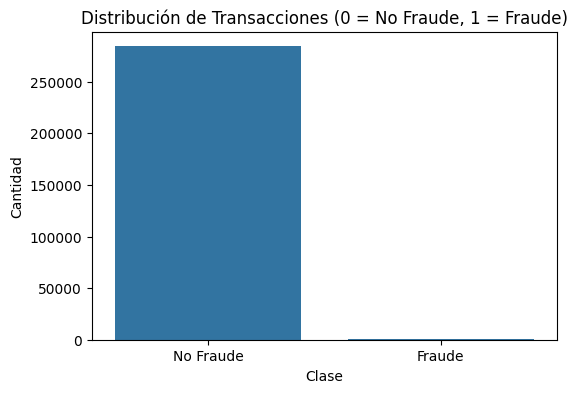


Porcentaje de transacciones fraudulentas: 0.1727%


In [3]:
# Conteo de clases
fraud_count = df['Class'].value_counts()

print("Distribución de clases:")
print(fraud_count)

# Visualización
plt.figure(figsize=(6,4))
sns.barplot(x=fraud_count.index, y=fraud_count.values)
plt.title('Distribución de Transacciones (0 = No Fraude, 1 = Fraude)')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.xticks([0,1], ['No Fraude', 'Fraude'])
plt.show()

# Porcentaje
fraud_percentage = (fraud_count[1] / fraud_count.sum()) * 100
print(f"\nPorcentaje de transacciones fraudulentas: {fraud_percentage:.4f}%")

In [4]:
# Verificar valores nulos
missing_values = df.isnull().sum()

# Mostrar solo columnas con valores nulos
missing_values[missing_values > 0]

Series([], dtype: int64)


Estadísticas de 'Amount':
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


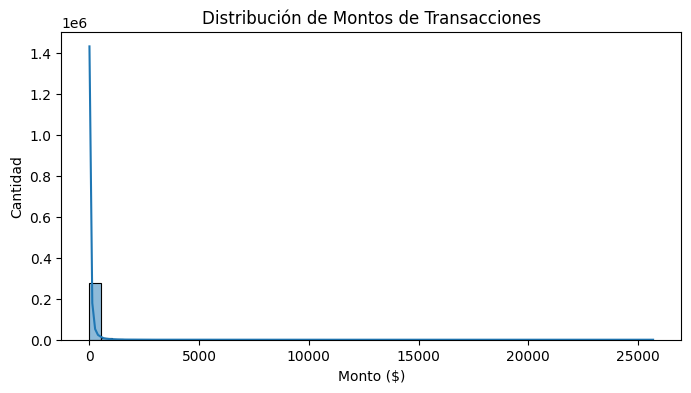


Estadísticas de 'Time':
count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


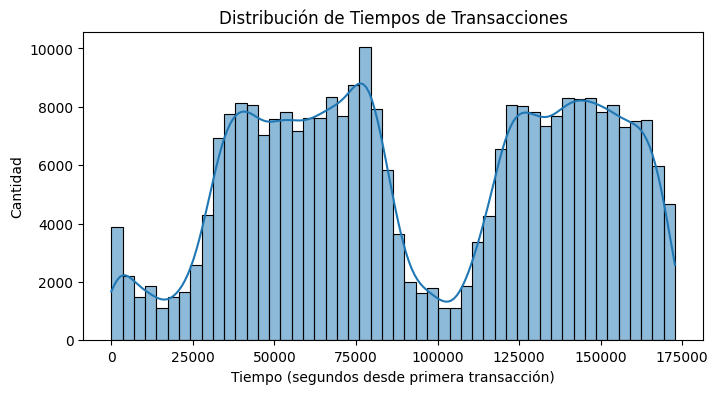

In [6]:
# 1. Estadísticas descriptivas generales
df.describe()

# 2. Análisis específico de 'Amount'
print("\nEstadísticas de 'Amount':")
print(df['Amount'].describe())

plt.figure(figsize=(8,4))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribución de Montos de Transacciones')
plt.xlabel('Monto ($)')
plt.ylabel('Cantidad')
plt.show()

# 3. Análisis específico de 'Time'
print("\nEstadísticas de 'Time':")
print(df['Time'].describe())

plt.figure(figsize=(8,4))
sns.histplot(df['Time'], bins=50, kde=True)
plt.title('Distribución de Tiempos de Transacciones')
plt.xlabel('Tiempo (segundos desde primera transacción)')
plt.ylabel('Cantidad')
plt.show()


Monto promedio de transacciones normales: 88.29102242231328
Monto promedio de transacciones fraudulentas: 122.21132113821139


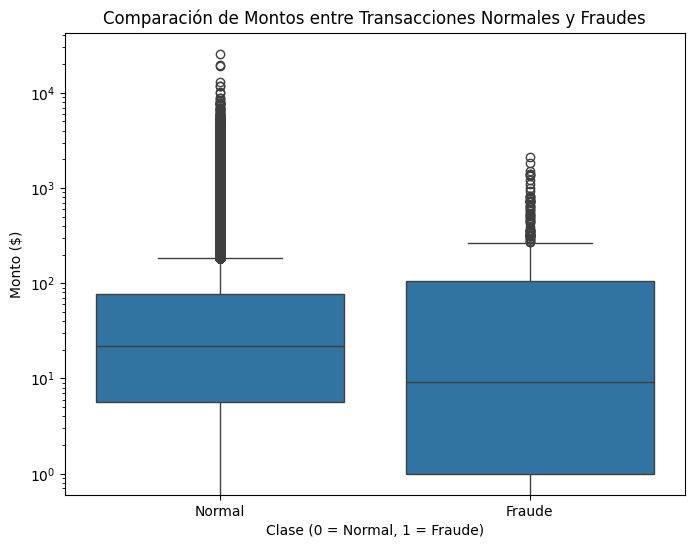

In [7]:
# Crear dos subconjuntos de datos
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

# Comparar montos
print("\nMonto promedio de transacciones normales:", normal['Amount'].mean())
print("Monto promedio de transacciones fraudulentas:", fraud['Amount'].mean())

# Boxplot de Amount
plt.figure(figsize=(8,6))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Comparación de Montos entre Transacciones Normales y Fraudes')
plt.xlabel('Clase (0 = Normal, 1 = Fraude)')
plt.ylabel('Monto ($)')
plt.xticks([0,1], ['Normal', 'Fraude'])
plt.yscale('log')  # Escala logarítmica para ver mejor los outliers
plt.show()


Correlaciones de las variables con 'Class':
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


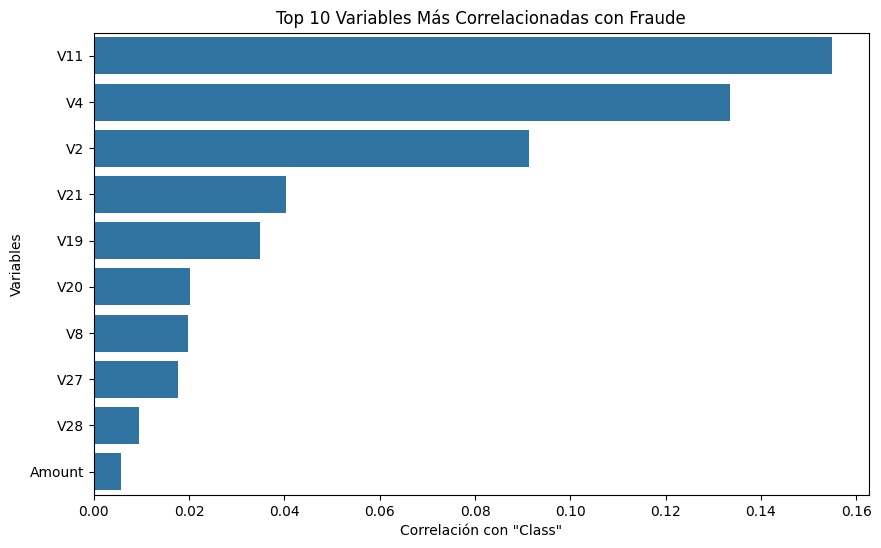

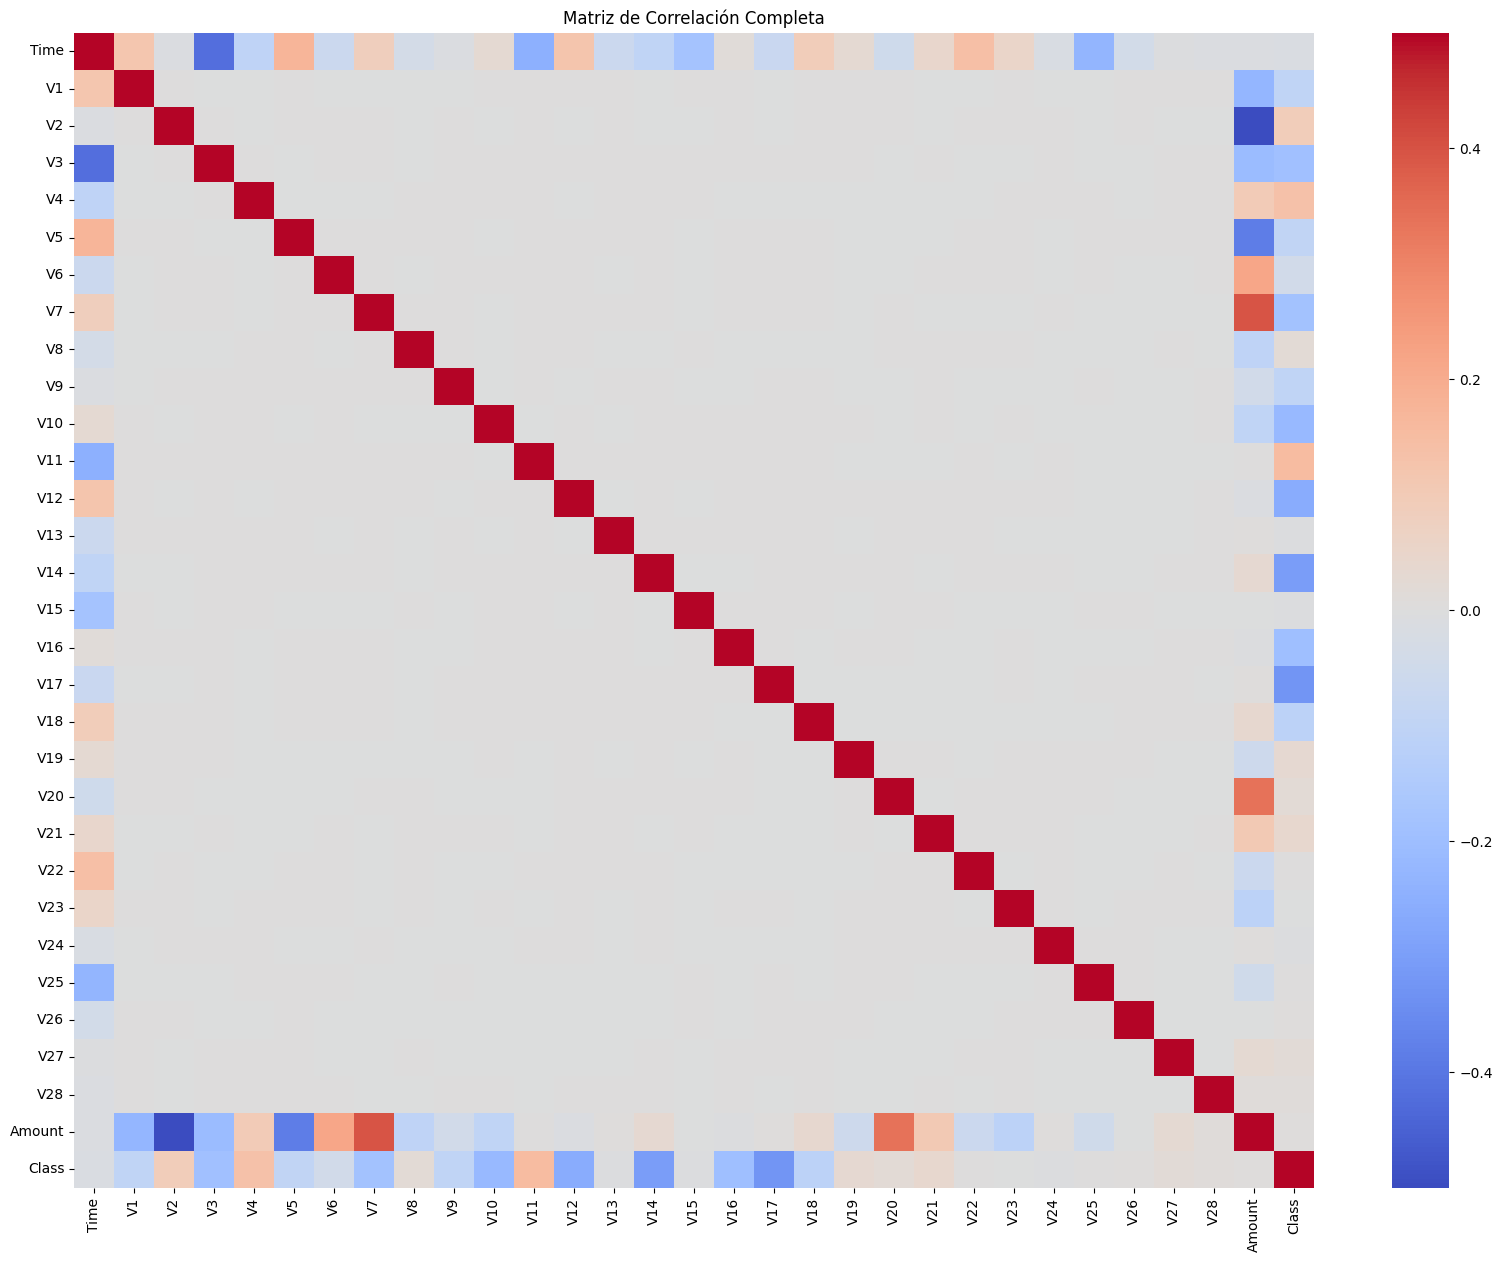

In [8]:
# 1. Matriz de correlación
correlation_matrix = df.corr()

# 2. Correlación de todas las variables respecto a 'Class'
correlations_with_class = correlation_matrix['Class'].sort_values(ascending=False)

print("\nCorrelaciones de las variables con 'Class':")
print(correlations_with_class)

# 3. Visualizar las 10 variables más correlacionadas
top_features = correlations_with_class[1:11]  # Quitamos 'Class' misma

plt.figure(figsize=(10,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title('Top 10 Variables Más Correlacionadas con Fraude')
plt.xlabel('Correlación con "Class"')
plt.ylabel('Variables')
plt.show()

# 4. Heatmap general (opcional pero recomendado)
plt.figure(figsize=(20,15))
sns.heatmap(correlation_matrix, cmap='coolwarm', vmax=0.5, vmin=-0.5)
plt.title('Matriz de Correlación Completa')
plt.show()

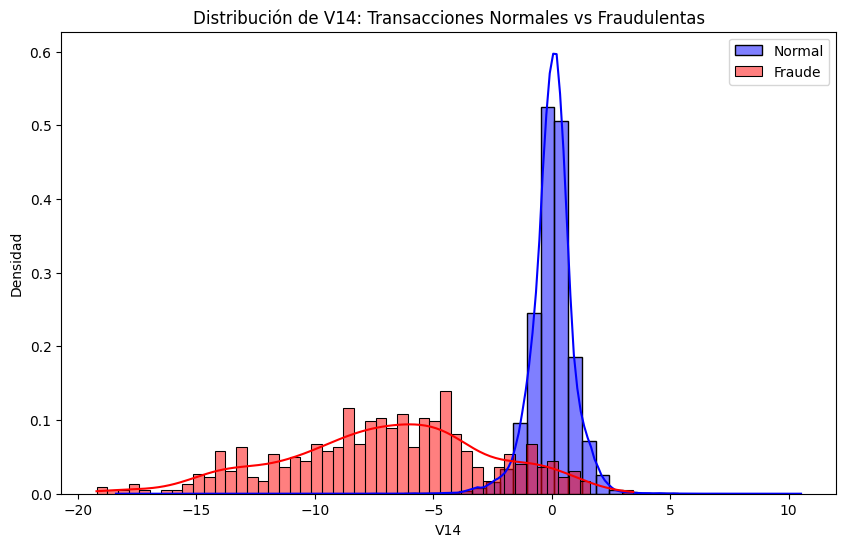

In [9]:
# Comparar la distribución de V14 entre normales y fraudes

plt.figure(figsize=(10,6))

# Histograma para transacciones normales
sns.histplot(df[df['Class'] == 0]['V14'], color='blue', label='Normal', bins=50, kde=True, stat="density")

# Histograma para transacciones fraudulentas
sns.histplot(df[df['Class'] == 1]['V14'], color='red', label='Fraude', bins=50, kde=True, stat="density")

plt.title('Distribución de V14: Transacciones Normales vs Fraudulentas')
plt.xlabel('V14')
plt.ylabel('Densidad')
plt.legend()
plt.show()